#Importing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#EDA

In [2]:
data=pd.read_csv("/content/drive/MyDrive/bikes.csv")

In [3]:
data.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count
0,2011-01-01 00:00:00,Spring,0.0,0.0,Clear,9.84,81.0,NaN,3,13,16
1,2011-01-01 01:00:00,Spring,0.0,0.0,NaN,9.02,80.0,0.0,8,32,40
2,2011-01-01 02:00:00,Spring,0.0,0.0,Clear,9.02,NaN,0.0,5,27,32
3,2011-01-01 03:00:00,Spring,0.0,0.0,Clear,9.84,75.0,0.0,3,10,13
4,2011-01-01 04:00:00,NaN,0.0,0.0,Clear,NaN,75.0,NaN,0,1,1


In [4]:
data.describe()

,holiday,workingday,temp,humidity,windspeed,casual,registered,rented_bikes_count
count,10030.000000,9388.000000,8104.000000,7462.000000,6820.000000,10886.000000,10886.000000,10886.000000
mean,0.029113,0.678206,20.317665,61.790673,12.708806,36.021955,155.552177,191.574132
std,0.168131,0.467189,7.818568,19.262084,8.131154,49.960477,151.039033,181.144454
min,0.000000,0.000000,0.820000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,13.940000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,0.000000,1.000000,20.500000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,0.000000,1.000000,26.240000,77.000000,16.997900,49.000000,222.000000,284.000000
max,1.000000,1.000000,41.000000,100.000000,56.996900,367.000000,886.000000,977.000000


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   datetime            10886 non-null  object 
 1   season              10672 non-null  object 
 2   holiday             10030 non-null  float64
 3   workingday          9388 non-null   float64
 4   weather             8746 non-null   object 
 5   temp                8104 non-null   float64
 6   humidity            7462 non-null   float64
 7   windspeed           6820 non-null   float64
 8   casual              10886 non-null  int64  
 9   registered          10886 non-null  int64  
 10  rented_bikes_count  10886 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 935.6+ KB


In [6]:
round(data.isnull().sum()/len(data)*100,2)

,0
datetime,0.00
season,1.97
holiday,7.86
workingday,13.76
weather,19.66
temp,25.56
humidity,31.45
windspeed,37.35
casual,0.00
registered,0.00


#Data Cleaning

In [7]:
data['datetime'] = pd.to_datetime(data['datetime'])

data['year'] = data['datetime'].dt.year
data['month'] = data['datetime'].dt.month
data['day'] = data['datetime'].dt.day
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek

In [8]:
data.drop('datetime', axis=1, inplace=True)

In [9]:
data.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,year,month,day,hour,day_of_week
0,Spring,0.0,0.0,Clear,9.84,81.0,NaN,3,13,16,2011,1,1,0,5
1,Spring,0.0,0.0,NaN,9.02,80.0,0.0,8,32,40,2011,1,1,1,5
2,Spring,0.0,0.0,Clear,9.02,NaN,0.0,5,27,32,2011,1,1,2,5
3,Spring,0.0,0.0,Clear,9.84,75.0,0.0,3,10,13,2011,1,1,3,5
4,NaN,0.0,0.0,Clear,NaN,75.0,NaN,0,1,1,2011,1,1,4,5


In [10]:
data.groupby('month').apply(lambda x: x['season'].mode())

season,0
month,
1,Spring
2,Spring
3,Spring
4,Summer
5,Summer
6,Summer
7,Fall
8,Fall
9,Fall


In [11]:
data['season'] = data['season'].fillna(data.groupby('month')['season'].transform(lambda x: x.mode()[0]))

In [12]:
round(data.isnull().sum()/len(data)*100,2)

,0
season,0.00
holiday,7.86
workingday,13.76
weather,19.66
temp,25.56
humidity,31.45
windspeed,37.35
casual,0.00
registered,0.00
rented_bikes_count,0.00


In [13]:
data['workingday'] = data['workingday'].fillna(data['day_of_week'].apply(lambda x: 1 if x <= 4 else 0))

In [14]:
round(data.isnull().sum()/len(data)*100,2)

,0
season,0.00
holiday,7.86
workingday,0.00
weather,19.66
temp,25.56
humidity,31.45
windspeed,37.35
casual,0.00
registered,0.00
rented_bikes_count,0.00


In [15]:
data.head()

,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,rented_bikes_count,year,month,day,hour,day_of_week
0,Spring,0.0,0.0,Clear,9.84,81.0,NaN,3,13,16,2011,1,1,0,5
1,Spring,0.0,0.0,NaN,9.02,80.0,0.0,8,32,40,2011,1,1,1,5
2,Spring,0.0,0.0,Clear,9.02,NaN,0.0,5,27,32,2011,1,1,2,5
3,Spring,0.0,0.0,Clear,9.84,75.0,0.0,3,10,13,2011,1,1,3,5
4,Spring,0.0,0.0,Clear,NaN,75.0,NaN,0,1,1,2011,1,1,4,5


In [16]:
data['weather'].fillna(data.groupby('season')['weather'].transform(lambda x : x.mode()[0]) , inplace = True)

In [17]:
cols = ['windspeed', 'humidity', 'temp']

for col in cols:
    data[col] = data[col].fillna(
        data.groupby(['weather', 'season'])[col].transform(lambda x: x.median()))

In [18]:
round(data.isnull().sum()/len(data)*100,2)

,0
season,0.00
holiday,7.86
workingday,0.00
weather,0.00
temp,0.00
humidity,0.00
windspeed,0.00
casual,0.00
registered,0.00
rented_bikes_count,0.00


In [19]:
data.drop(['holiday', 'casual', 'registered', 'day_of_week'], axis=1, inplace=True)

In [20]:
data.columns

Index(['season', 'workingday', 'weather', 'temp', 'humidity', 'windspeed',
       'rented_bikes_count', 'year', 'month', 'day', 'hour'],
      dtype='object')

In [21]:
round(data.isnull().sum()/len(data)*100,2)

,0
season,0.0
workingday,0.0
weather,0.0
temp,0.0
humidity,0.0
windspeed,0.0
rented_bikes_count,0.0
year,0.0
month,0.0
day,0.0


#Feature Engineering

In [22]:
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

data['Time_of_day'] = data['hour'].apply(get_time_of_day)

In [23]:
# Encoding Categorical Columns
cols_to_encode = ['season', 'Time_of_day', 'weather']

data = pd.get_dummies(data, columns=cols_to_encode, drop_first=True)

In [24]:
data.head()

,workingday,temp,humidity,windspeed,rented_bikes_count,year,month,day,hour,season_Spring,season_Summer,season_Winter,Time_of_day_Evening,Time_of_day_Morning,Time_of_day_Night,weather_Mist,weather_Rainy,weather_Snowy
0,0.0,9.84,81.0,15.0013,16,2011,1,1,0,True,False,False,False,False,True,False,False,False
1,0.0,9.02,80.0,0.0000,40,2011,1,1,1,True,False,False,False,False,True,False,False,False
2,0.0,9.02,50.0,0.0000,32,2011,1,1,2,True,False,False,False,False,True,False,False,False
3,0.0,9.84,75.0,0.0000,13,2011,1,1,3,True,False,False,False,False,True,False,False,False
4,0.0,12.30,75.0,15.0013,1,2011,1,1,4,True,False,False,False,False,True,False,False,False


#Data Visualization

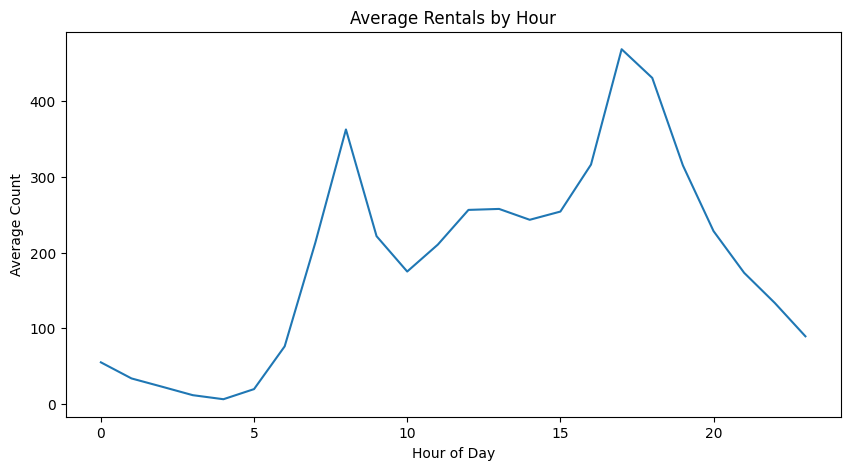

In [25]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='rented_bikes_count', data=data, estimator='mean', ci=None)
plt.title('Average Rentals by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Count')
plt.show()

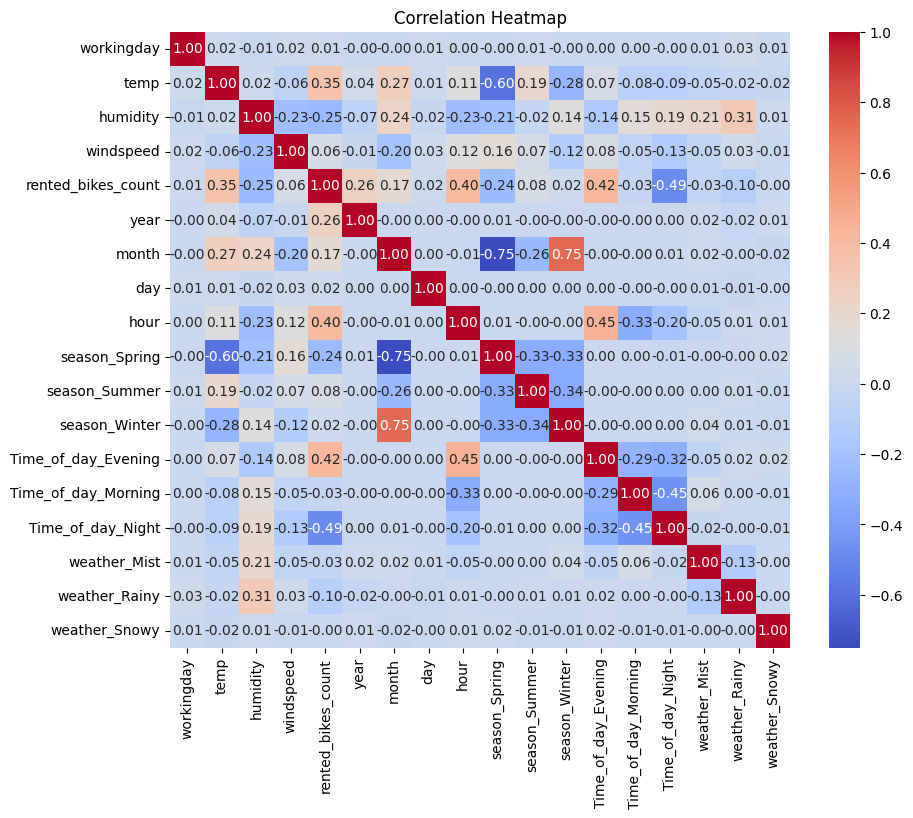

In [26]:
plt.figure(figsize=(10,8))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap')
plt.show()

In [33]:
data.to_pickle('/content/drive/MyDrive/my_data.pkl')

#Modeling

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [28]:
y = data['rented_bikes_count']
X = data.drop('rented_bikes_count', axis=1)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)

DecisionTreeRegressor()

In [32]:
y_pred = dt_model.predict(X_test)

# تقييم الأداء
mse = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error: 40.48
R² Score: 0.86
